In [ ]:
# 查看当前挂载的数据集目录, 该目录下的变更重启环境后会自动还原
# View dataset directory. 
# This directory will be recovered automatically after resetting environment. 
!ls /home/aistudio/data

In [ ]:
# 查看工作区文件，该目录下除data目录外的变更将会持久保存。请及时清理不必要的文件，避免加载过慢。
# View personal work directory. 
# All changes, except /data, under this directory will be kept even after reset. 
# Please clean unnecessary files in time to speed up environment loading. 
!ls /home/aistudio

In [ ]:
# 如果需要进行持久化安装, 需要使用持久化路径, 如下方代码示例:
# If a persistence installation is required, 
# you need to use the persistence path as the following: 
!mkdir /home/aistudio/external-libraries
!pip install beautifulsoup4 -t /home/aistudio/external-libraries

In [ ]:
# 同时添加如下代码, 这样每次环境(kernel)启动的时候只要运行下方代码即可: 
# Also add the following code, 
# so that every time the environment (kernel) starts, 
# just run the following code: 
import sys 
sys.path.append('/home/aistudio/external-libraries')

# 11-1 从BGR空间转换到RGB空间

# 11-5 利用cv2.split()

# 11-6 彩色图像通道的合并


## 1. 使用 split 和 merge

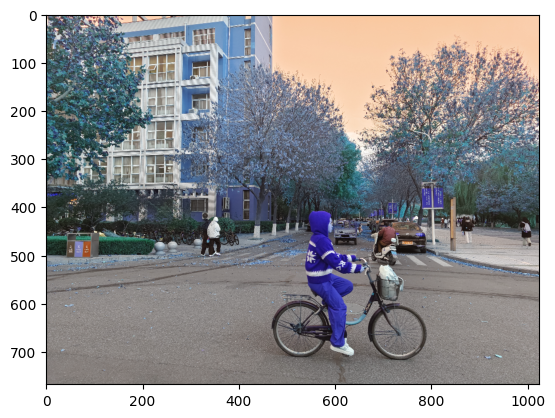

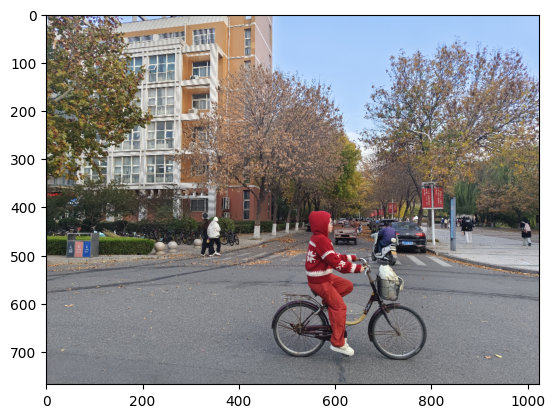

Text(0.5, 1.0, 'rgb')

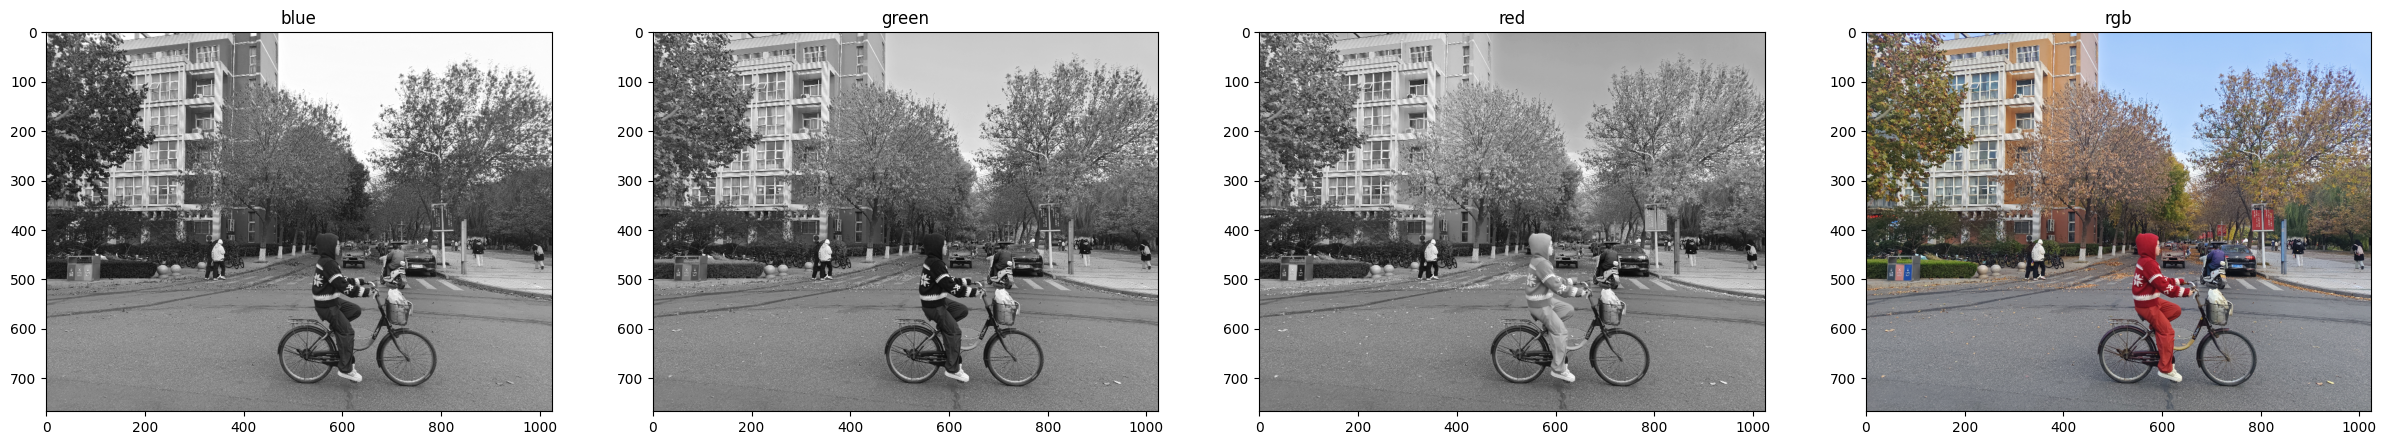

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])



plt.imshow(bgr) 
plt.show()

plt.imshow(rgb) 
plt.show()

fig,ax = plt.subplots(1,4,figsize=(30,10),dpi = 100)
ax[0].imshow(b,cmap = 'gray',label ='blue')
ax[0].set_title('blue')
ax[1].imshow(g,cmap ='gray',label ='green')
ax[1].set_title('green')
ax[2].imshow(r,cmap ='gray',label = 'red')
ax[2].set_title('red')
ax[3].imshow(rgb,label = 'rgb')
ax[3].set_title('rgb')




## 2.使用numpy，不使用自带函数

(768, 1024, 3)


Text(0.5, 1.0, 'rgb')

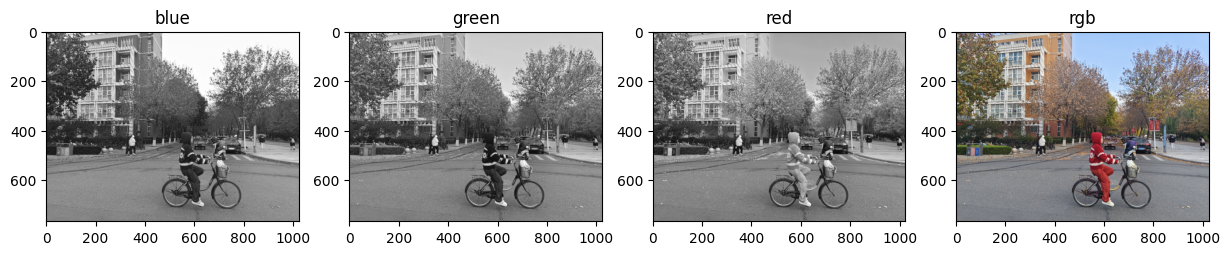

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
print(bgr.shape)
b = bgr[:,:,0]
g = bgr[:,:,1]
r = bgr[:,:,2]
rgb = np.zeros(bgr.shape,dtype = bgr.dtype)
rgb[:,:,0] = r
rgb[:,:,1] = g
rgb[:,:,2] = b

np.stack

#b,g,r  = cv2.split(bgr)
#rgb = cv2.merge([r,g,b])



fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(b,cmap = 'gray',label ='blue')
ax[0].set_title('blue')
ax[1].imshow(g,cmap ='gray',label ='green')
ax[1].set_title('green')
ax[2].imshow(r,cmap ='gray',label = 'red')
ax[2].set_title('red')
ax[3].imshow(rgb,label = 'rgb')
ax[3].set_title('rgb')




## 3. 使用np.stack

(768, 1024, 3)


Text(0.5, 1.0, 'rgb')

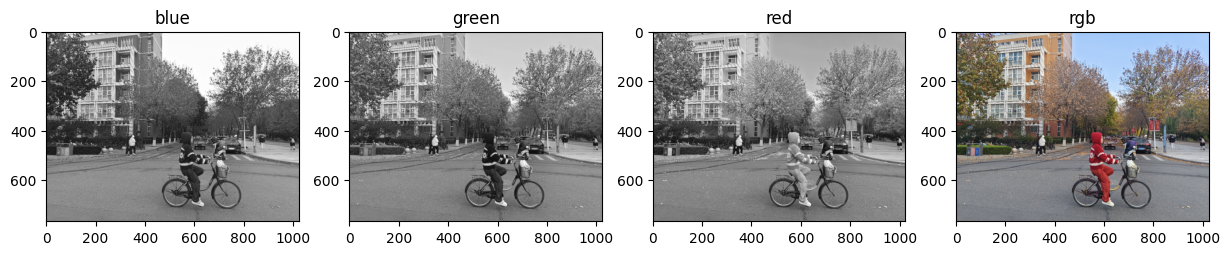

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
print(bgr.shape)
b = bgr[:,:,0]
g = bgr[:,:,1]
r = bgr[:,:,2]
rgb = np.stack([r,g,b],axis = 2)
#rgb = np.zeros(bgr.shape,dtype = bgr.dtype)
#rgb[:,:,0] = r
#rgb[:,:,1] = g
#rgb[:,:,2] = b


#b,g,r  = cv2.split(bgr)
#rgb = cv2.merge([r,g,b])



fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(b,cmap = 'gray',label ='blue')
ax[0].set_title('blue')
ax[1].imshow(g,cmap ='gray',label ='green')
ax[1].set_title('green')
ax[2].imshow(r,cmap ='gray',label = 'red')
ax[2].set_title('red')
ax[3].imshow(rgb,label = 'rgb')
ax[3].set_title('rgb')




# 11-4 从RGB空间到HSV空间的转换

## 1.实现hsv函数的相互转换

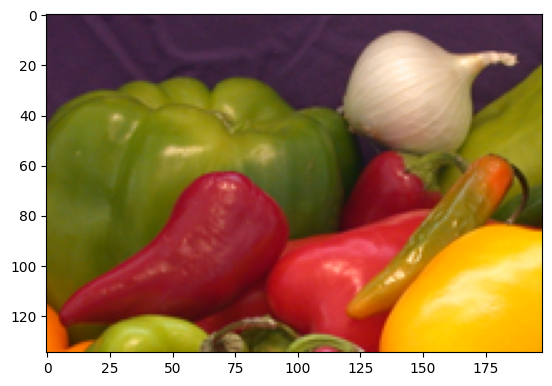

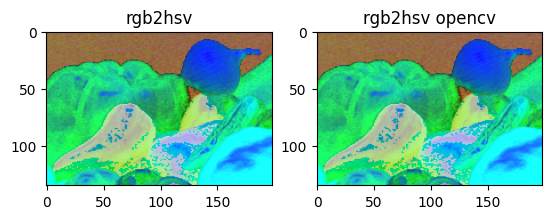

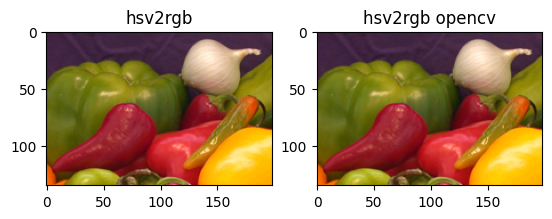

In [17]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 

def rgb2hsv(rgb_image):
    '''  in range rgb 0-255
        out range 
        h 0-180
        s 0-255
        v 0-255
    '''
    rows,cols,channels = rgb_image.shape
    rgb_01 = rgb_image.copy()
    rgb_01 = rgb_image.astype(np.float64)/255.0
    r = rgb_01[:,:,0]
    g = rgb_01[:,:,1]
    b = rgb_01[:,:,2]
    vmax =np.maximum(np.maximum(r,g) ,b)
    vmin = np.minimum(np.minimum(r,g),b)  
    H = np.zeros((rows,cols),dtype = np.float64)
    S = np.zeros((rows,cols),dtype = np.float64)
    V = np.zeros((rows,cols),dtype = np.float64)
    max_pos = np.argmax(rgb_01,axis=2)
    max_equal_min_pos = vmax==vmin # situation1 
    r_max = max_pos == 0
    g_bigger_b_pos = g >= b
    g_smaller_b_pos = g < b
    r_max_g_bigger_b = r_max & g_bigger_b_pos # situation 2
    r_max_g_smaller_b = r_max & g_smaller_b_pos # situation 3
    g_max = max_pos == 1 # situation 4
    b_max = max_pos == 2 #situation 5
    mask1 = max_equal_min_pos
    mask2 = r_max_g_bigger_b
    mask3 = r_max_g_smaller_b
    mask4 =  g_max 
    mask5 =  b_max
    H[mask1] = 0
    H[mask2] = 60 * ((g[mask2]-b[mask2])/(vmax[mask2]-vmin[mask2])) + 0
    H[mask3] = 60 * ((g[mask3]-b[mask3])/(vmax[mask3]-vmin[mask3])) + 360
    H[mask4] = 60 * ((b[mask4]-r[mask4])/(vmax[mask4]-vmin[mask4])) + 120
    H[mask5] = 60 * ((r[mask5]-g[mask5])/(vmax[mask5]-vmin[mask5])) + 240
    mask1_s = vmax==0
    mask2_s = vmax!=0
    S[mask1_s] = 0
    S[mask2_s] = 1 - vmin[mask2_s]/vmax[mask2_s]
    V = vmax
    H_new = H/2.0
    S_new = S*255
    V_new = V*255
    hsv_image = np.dstack((H_new,S_new,V_new))
    hsv_image_out = hsv_image.astype(np.uint8)
    return hsv_image_out

def hsv2rgb(hsv_image):

    '''  in range h 0-180
                  s 0-255
                  v 0-255
        out range rgb 0-255
    '''
    rows,cols,channels = hsv_image.shape
    H = hsv_image[:,:,0]
    S = hsv_image[:,:,1]
    V = hsv_image[:,:,2]

    H = (H.copy().astype(np.int32)*2)%360
    S = S.copy().astype(np.float64)/255.0
    V = V.copy().astype(np.float64)/255.0
    C= V * S
    m = V - C  
    X = C *(1- np.abs((H/60) % 2 -1 ))
    mask_a  = H >=0
    mask_b = H < 60
    mask0 = mask_a & mask_b
    mask_a = H>=60 
    mask_b = H < 120
    mask1 = mask_a & mask_b
    mask_a = H>=120 
    mask_b = H < 180
    mask2 = mask_a & mask_b 
    mask_a = H>=180 
    mask_b = H < 240
    mask3 = mask_a & mask_b
    mask_a = H>=240 
    mask_b = H < 300
    mask4 = mask_a & mask_b
    mask_a = H>=300 
    mask_b = H < 360
    mask5 = mask_a & mask_b
    Rp= np.zeros((rows,cols),dtype = np.float64)
    Gp = np.zeros((rows,cols),dtype = np.float64)
    Bp = np.zeros((rows,cols),dtype = np.float64)
    Rp[mask0] = C[mask0]
    Rp[mask1] = X[mask1]
    Rp[mask2] = 0
    Rp[mask3] = 0
    Rp[mask4] = X[mask4]
    Rp[mask5] = C[mask5]

    Gp[mask0] = X[mask0]
    Gp[mask1] = C[mask1]
    Gp[mask2] = C[mask2]
    Gp[mask3] = X[mask3]
    Gp[mask4] = 0
    Gp[mask5] = 0

    Bp[mask0] = 0
    Bp[mask1] = 0
    Bp[mask2] = X[mask2]
    Bp[mask3] = C[mask3]
    Bp[mask4] = C[mask4]
    Bp[mask5] = X[mask5]

    R = (Rp + m)*255
    G = (Gp + m)*255
    B = (Bp + m )*255
    rgb_image = np.dstack((R,G,B))
    rgb_image = rgb_image.astype(np.uint8)   
    return rgb_image



bgr_image = cv2.imread('onion.png')
b,g,r = cv2.split(bgr_image)
rgb_image = cv2.merge([r,g,b] )

hsv_image = rgb2hsv(rgb_image)
rgb_from_hsv_image = hsv2rgb(hsv_image)
hsv_opencv_image = cv2.cvtColor(rgb_image,cv2.COLOR_RGB2HSV)
rgb_from_hsv_opencv_image =cv2.cvtColor(hsv_opencv_image,cv2.COLOR_HSV2RGB)

plt.imshow(rgb_image)
plt.show()
plt.subplot(1,2,1)
plt.imshow(rgb2hsv(rgb_image))
plt.title('rgb2hsv')
plt.subplot(1,2,2)
plt.imshow(hsv_opencv_image)
plt.title('rgb2hsv opencv')
plt.show()



plt.subplot(1,2,1)
plt.imshow(rgb_from_hsv_image)
plt.title('hsv2rgb')
plt.subplot(1,2,2)
plt.imshow(rgb_from_hsv_opencv_image)
plt.title('hsv2rgb opencv')
plt.show()










## 2.使用rgb2hsv函数显示图片

/tmp/ipykernel_260/346174960.py:38: RuntimeWarning: invalid value encountered in divide
  H[mask2] = 60 * ((g[mask2]-b[mask2])/(vmax[mask2]-vmin[mask2])) + 0
/tmp/ipykernel_260/346174960.py:51: RuntimeWarning: invalid value encountered in cast
  hsv_image_out = hsv_image.astype(np.uint8)


Text(0.5, 1.0, 'rgb')

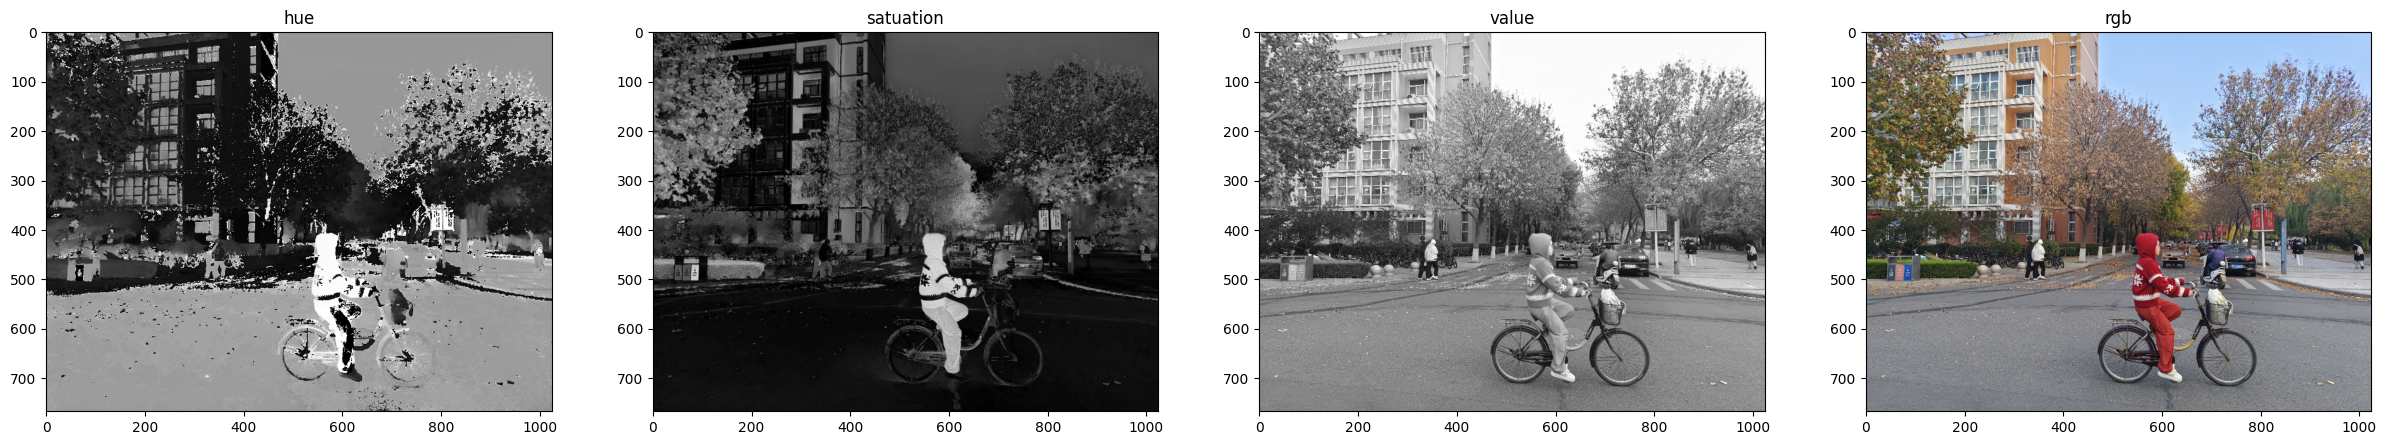

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 

def rgb2hsv(rgb_image):
    '''  in range rgb 0-255
        out range 
        h 0-180
        s 0-255
        v 0-255
    '''
    rows,cols,channels = rgb_image.shape
    rgb_01 = rgb_image.copy()
    rgb_01 = rgb_image.astype(np.float64)/255.0
    r = rgb_01[:,:,0]
    g = rgb_01[:,:,1]
    b = rgb_01[:,:,2]
    vmax =np.maximum(np.maximum(r,g) ,b)
    vmin = np.minimum(np.minimum(r,g),b)  
    H = np.zeros((rows,cols),dtype = np.float64)
    S = np.zeros((rows,cols),dtype = np.float64)
    V = np.zeros((rows,cols),dtype = np.float64)
    max_pos = np.argmax(rgb_01,axis=2)
    max_equal_min_pos = vmax==vmin # situation1 
    r_max = max_pos == 0
    g_bigger_b_pos = g >= b
    g_smaller_b_pos = g < b
    r_max_g_bigger_b = r_max & g_bigger_b_pos # situation 2
    r_max_g_smaller_b = r_max & g_smaller_b_pos # situation 3
    g_max = max_pos == 1 # situation 4
    b_max = max_pos == 2 #situation 5
    mask1 = max_equal_min_pos
    mask2 = r_max_g_bigger_b
    mask3 = r_max_g_smaller_b
    mask4 =  g_max 
    mask5 =  b_max
    H[mask1] = 0
    H[mask2] = 60 * ((g[mask2]-b[mask2])/(vmax[mask2]-vmin[mask2])) + 0
    H[mask3] = 60 * ((g[mask3]-b[mask3])/(vmax[mask3]-vmin[mask3])) + 360
    H[mask4] = 60 * ((b[mask4]-r[mask4])/(vmax[mask4]-vmin[mask4])) + 120
    H[mask5] = 60 * ((r[mask5]-g[mask5])/(vmax[mask5]-vmin[mask5])) + 240
    mask1_s = vmax==0
    mask2_s = vmax!=0
    S[mask1_s] = 0
    S[mask2_s] = 1 - vmin[mask2_s]/vmax[mask2_s]
    V = vmax
    H_new = H/2.0
    S_new = S*255
    V_new = V*255
    hsv_image = np.dstack((H_new,S_new,V_new))
    hsv_image_out = hsv_image.astype(np.uint8)
    return hsv_image_out

def hsv2rgb(hsv_image):

    '''  in range h 0-180
                  s 0-255
                  v 0-255
        out range rgb 0-255
    '''
    rows,cols,channels = hsv_image.shape
    H = hsv_image[:,:,0]
    S = hsv_image[:,:,1]
    V = hsv_image[:,:,2]

    H = (H.copy().astype(np.int32)*2)%360
    S = S.copy().astype(np.float64)/255.0
    V = V.copy().astype(np.float64)/255.0
    C= V * S
    m = V - C  
    X = C *(1- np.abs((H/60) % 2 -1 ))
    mask_a  = H >=0
    mask_b = H < 60
    mask0 = mask_a & mask_b
    mask_a = H>=60 
    mask_b = H < 120
    mask1 = mask_a & mask_b
    mask_a = H>=120 
    mask_b = H < 180
    mask2 = mask_a & mask_b 
    mask_a = H>=180 
    mask_b = H < 240
    mask3 = mask_a & mask_b
    mask_a = H>=240 
    mask_b = H < 300
    mask4 = mask_a & mask_b
    mask_a = H>=300 
    mask_b = H < 360
    mask5 = mask_a & mask_b
    Rp= np.zeros((rows,cols),dtype = np.float64)
    Gp = np.zeros((rows,cols),dtype = np.float64)
    Bp = np.zeros((rows,cols),dtype = np.float64)
    Rp[mask0] = C[mask0]
    Rp[mask1] = X[mask1]
    Rp[mask2] = 0
    Rp[mask3] = 0
    Rp[mask4] = X[mask4]
    Rp[mask5] = C[mask5]

    Gp[mask0] = X[mask0]
    Gp[mask1] = C[mask1]
    Gp[mask2] = C[mask2]
    Gp[mask3] = X[mask3]
    Gp[mask4] = 0
    Gp[mask5] = 0

    Bp[mask0] = 0
    Bp[mask1] = 0
    Bp[mask2] = X[mask2]
    Bp[mask3] = C[mask3]
    Bp[mask4] = C[mask4]
    Bp[mask5] = X[mask5]

    R = (Rp + m)*255
    G = (Gp + m)*255
    B = (Bp + m )*255
    rgb_image = np.dstack((R,G,B))
    rgb_image = rgb_image.astype(np.uint8)   
    return rgb_image



bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
hsv = rgb2hsv(rgb)

h,s,v = cv2.split(hsv)

fig,ax = plt.subplots(1,4,figsize=(30,10),dpi = 100)
ax[0].imshow(h,cmap = 'gray')
ax[0].set_title('hue')
ax[1].imshow(s,cmap ='gray')
ax[1].set_title('satuation')
ax[2].imshow(v,cmap ='gray')
ax[2].set_title('value')
ax[3].imshow(rgb,label = 'rgb')
ax[3].set_title('rgb')




## 3.使用opencv颜色转换函数
![](cvtcolor1.jpg)
![](cvtcolor2.jpg)
![](cvtcolor3.jpg)
![](cvtcolor4.jpg)

Text(0.5, 1.0, 'rgb')

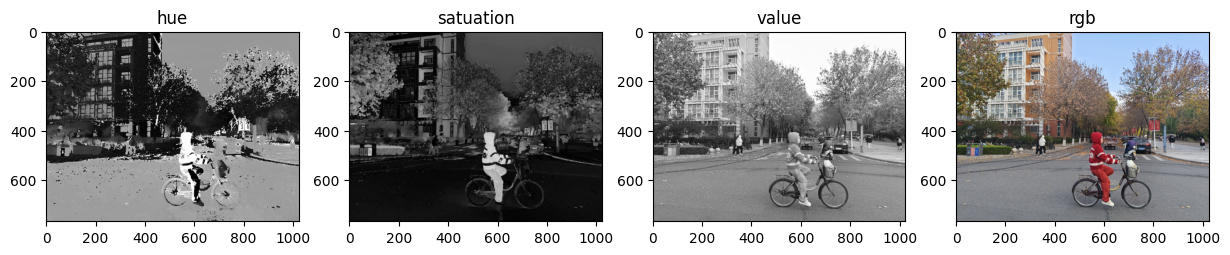

In [20]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
hsv = cv2.cvtColor(rgb,cv2.COLOR_RGB2HSV)

h,s,v = cv2.split(hsv)

fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(h,cmap = 'gray')
ax[0].set_title('hue')
ax[1].imshow(s,cmap ='gray')
ax[1].set_title('satuation')
ax[2].imshow(v,cmap ='gray')
ax[2].set_title('value')
ax[3].imshow(rgb,label = 'rgb')
ax[3].set_title('rgb')


# 11-2 Gray色彩空间
$ Gray = 0.299R + 0.587G + 0.114B$

## 1. gray 拆分通道直接求

Text(0.5, 1.0, 'gray')

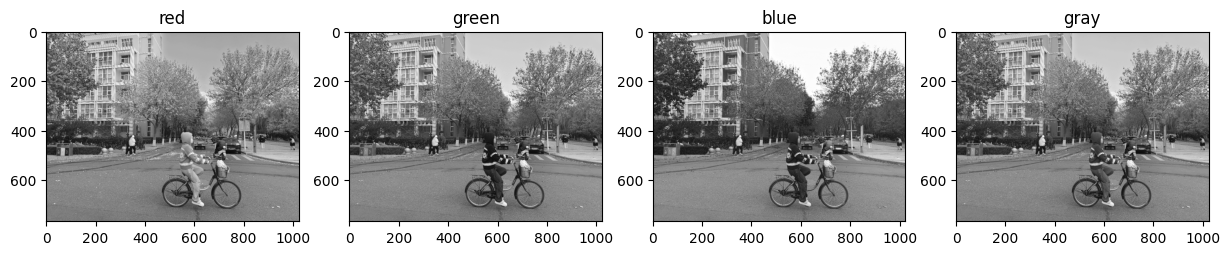

In [23]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
def rgb2gray(rgb):
    r,g,b =cv2.split(rgb) 
    r = r.astype(np.float64)
    g = g.astype(np.float64)
    b = b.astype(np.float64)
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    gray = np.clip(gray,0,255).astype(np.uint8)
    return gray

bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
gray = rgb2gray(rgb)

fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(r,cmap = 'gray')
ax[0].set_title('red')
ax[1].imshow(g,cmap ='gray')
ax[1].set_title('green')
ax[2].imshow(b,cmap ='gray')
ax[2].set_title('blue')
ax[3].imshow(gray,cmap = 'gray')
ax[3].set_title('gray')

## 2.使用矩阵乘法  numpy  np.matmul  

True
[[220 118  87 ... 201 201 201]
 [208 102  77 ... 202 202 201]
 [229 230 212 ... 201 202 203]
 ...
 [130 126 126 ... 136 143 141]
 [126 124 122 ... 124 137 141]
 [123 126 128 ... 128 127 131]]
[[220 118  87 ... 201 201 201]
 [208 102  77 ... 202 202 201]
 [229 230 212 ... 201 202 203]
 ...
 [130 126 126 ... 136 143 141]
 [126 124 122 ... 124 137 141]
 [123 126 128 ... 128 127 131]]


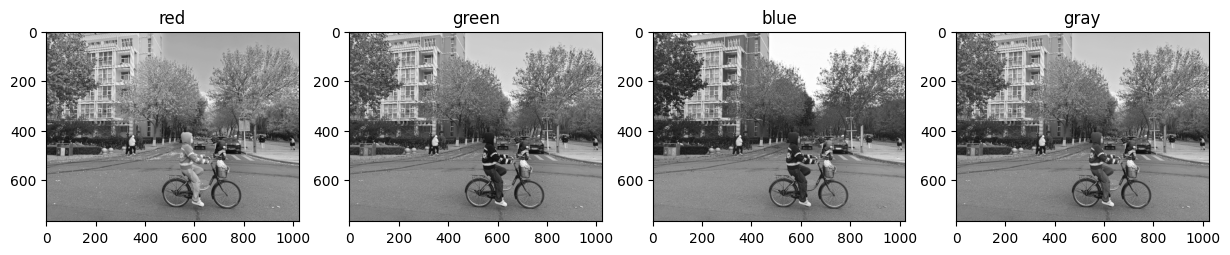

In [26]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
def rgb2gray_matmul(rgb):
    rgb=rgb.astype(np.float64)
    kernel = np.array([0.2989,0.587,0.114])
    gray = rgb @  kernel
    gray = np.clip(np.around(gray,decimals = 0),0,255).astype(np.uint8)
    return gray

bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
gray = rgb2gray_matmul(rgb)

gray_cv2 = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)




fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(r,cmap = 'gray')
ax[0].set_title('red')
ax[1].imshow(g,cmap ='gray')
ax[1].set_title('green')
ax[2].imshow(b,cmap ='gray')
ax[2].set_title('blue')
ax[3].imshow(gray,cmap = 'gray')
ax[3].set_title('gray')


print(np.allclose(gray,gray_cv2,atol=1))
print(gray_cv2)
print(gray)

## 3.使用 np.einsum()
如果需要详细了解，请看

[知乎上的一篇介绍einsum函数文章](https://zhuanlan.zhihu.com/p/71639781)

True
[[220 118  87 ... 201 201 201]
 [208 102  77 ... 202 202 201]
 [229 230 212 ... 201 202 203]
 ...
 [130 126 126 ... 136 143 141]
 [126 124 122 ... 124 137 141]
 [123 126 128 ... 128 127 131]]
[[220 118  87 ... 201 201 201]
 [208 102  77 ... 202 202 201]
 [229 230 212 ... 201 202 203]
 ...
 [130 126 126 ... 136 143 141]
 [126 124 122 ... 124 137 141]
 [123 126 128 ... 128 127 131]]


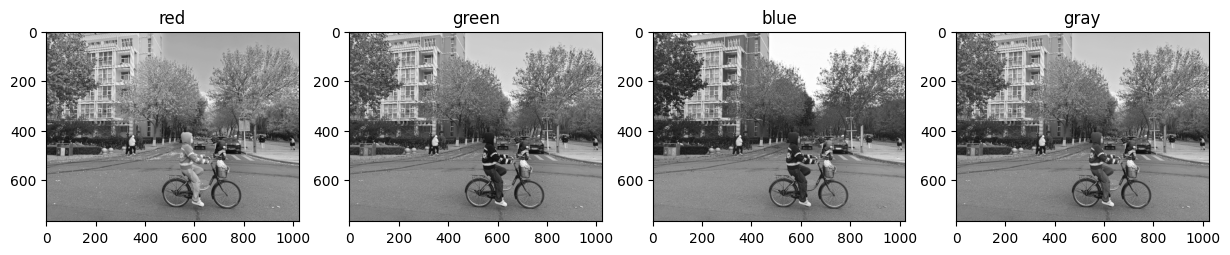

In [29]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
def rgb2gray_matmul(rgb):
    rgb=rgb.astype(np.float64)
    kernel = np.array([0.2989,0.587,0.114])
    gray = np.einsum('ijk,k->ij',rgb,kernel)
    gray = np.clip(np.around(gray,decimals = 0),0,255).astype(np.uint8)
    return gray

bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
gray = rgb2gray_matmul(rgb)

gray_cv2 = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)
fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(r,cmap = 'gray')
ax[0].set_title('red')
ax[1].imshow(g,cmap ='gray')
ax[1].set_title('green')
ax[2].imshow(b,cmap ='gray')
ax[2].set_title('blue')
ax[3].imshow(gray,cmap = 'gray')
ax[3].set_title('gray')


print(np.allclose(gray,gray_cv2,atol=1))
print(gray_cv2)
print(gray)

In [28]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 

img = np.arange(0,3*4*3).reshape(3,4,3)

kernel = np.array([1,2,3])
kernel2 = kernel[:,None]


result_multi = img @ kernel
result_einsum = np.einsum('ijk,k->ij',img,kernel)
print(result_einsum)
print(kernel)
print(img)
print(result_multi)
print(kernel2)
result_multi2  = img@ kernel2
print(kernel2.shape)
print(result_multi2[:,:,0])
print(result_multi2.shape)

[[  8  26  44  62]
 [ 80  98 116 134]
 [152 170 188 206]]
[1 2 3]
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]]

 [[12 13 14]
  [15 16 17]
  [18 19 20]
  [21 22 23]]

 [[24 25 26]
  [27 28 29]
  [30 31 32]
  [33 34 35]]]
[[  8  26  44  62]
 [ 80  98 116 134]
 [152 170 188 206]]
[[1]
 [2]
 [3]]
(3, 1)
[[  8  26  44  62]
 [ 80  98 116 134]
 [152 170 188 206]]
(3, 4, 1)


In [16]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 

img = np.arange(0,3*4*3).reshape(3,4,3)

kernel = np.array([1,2,3])
kernel2 = kernel[:,None]


result_multi = img @ kernel
print(kernel)
print(img)
print(result_multi)
print(kernel2)
result_multi2  = img@ kernel2
print(kernel2.shape)
print(result_multi2[:,:,0])
print(result_multi2.shape)



[1 2 3]
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]]

 [[12 13 14]
  [15 16 17]
  [18 19 20]
  [21 22 23]]

 [[24 25 26]
  [27 28 29]
  [30 31 32]
  [33 34 35]]]
[[  8  26  44  62]
 [ 80  98 116 134]
 [152 170 188 206]]
[[1]
 [2]
 [3]]
(3, 1)
[[  8  26  44  62]
 [ 80  98 116 134]
 [152 170 188 206]]
(3, 4, 1)


# 11-3 YCbCr
$Y = 0.299*R + 0.587*G + 0.114*B$

$Cr = (R-Y)*0.713 + delta$

$Cb =(B-Y)*0.564 + delta$

$delta = 128 $

$M_{rgb2YCbCr} =
\begin{bmatrix}
  0.299 & 0.587 & 0.114 \\
  -0.169 & -0.331 & 0.500\\
  0.500 & -0.419 & -0.081
\end{bmatrix}
 \begin{bmatrix}
 R \\G\\B
 \end{bmatrix} +\begin{bmatrix} 0 \\128\\ 128\end{bmatrix}$

![](ycbcr.jpg)

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
a = np.array([1,2,3])
print(a)
print(a.shape)


[1 2 3]
(3,)


True
[[[220 117 141]
  [118 123 169]
  [ 87 135 154]
  ...
  [201 107 156]
  [201 107 156]
  [201 107 156]]

 [[208 110 144]
  [102 118 174]
  [ 77 126 170]
  ...
  [202 108 156]
  [202 107 156]
  [201 108 155]]

 [[229 111 142]
  [230 111 142]
  [212 107 151]
  ...
  [201 108 155]
  [202 108 155]
  [203 108 155]]

 ...

 [[130 127 131]
  [126 127 131]
  [126 127 131]
  ...
  [136 126 130]
  [143 126 130]
  [141 126 130]]

 [[126 127 131]
  [124 127 131]
  [122 127 131]
  ...
  [124 126 131]
  [137 126 131]
  [141 126 130]]

 [[123 127 131]
  [126 127 131]
  [128 127 131]
  ...
  [128 126 130]
  [127 126 131]
  [131 126 130]]]
[[[220 117 140]
  [118 123 169]
  [ 87 134 153]
  ...
  [201 107 156]
  [201 107 156]
  [201 107 156]]

 [[208 110 144]
  [102 118 174]
  [ 77 126 170]
  ...
  [202 108 156]
  [202 107 156]
  [201 107 155]]

 [[229 111 143]
  [230 111 142]
  [212 107 151]
  ...
  [201 108 155]
  [202 108 155]
  [203 108 155]]

 ...

 [[130 127 131]
  [126 127 131]
  [126 127 131]

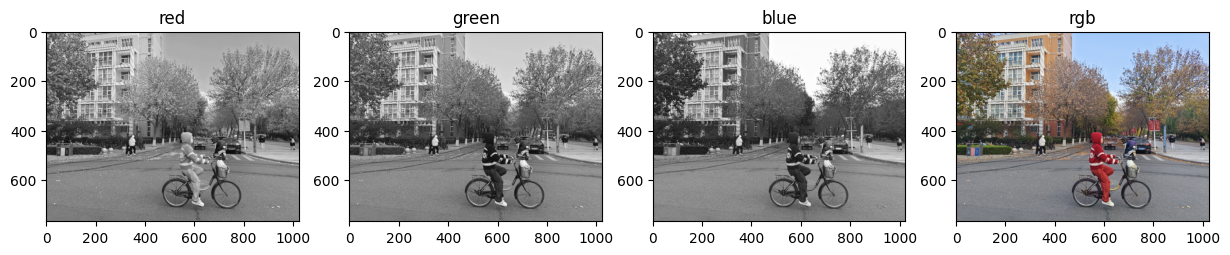

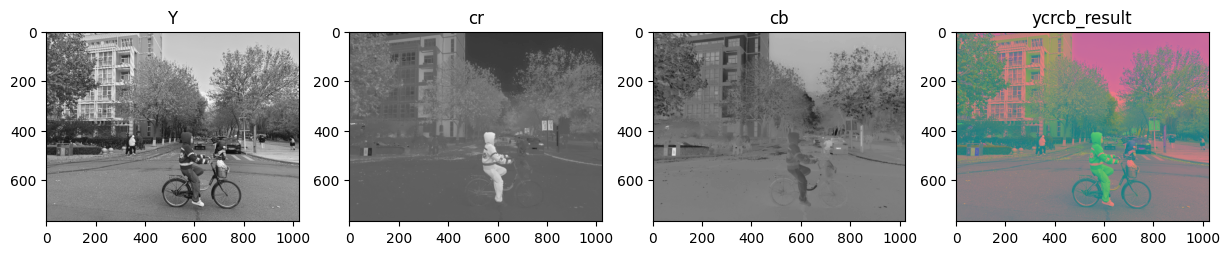

In [50]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
def rgb2ycrcb(rgb):
    rgb=rgb.astype(np.float64)
    ycrcb = np.array([[0.299,0.499813,-0.168935],[0.587,-0.418531,-0.331665],[0.114,-0.081282,0.50059]])
    ycrcb_bias = np.array([0,128,128])
    result_einsum = np.einsum('ijk,ks->ijs',rgb,ycrcb) + ycrcb_bias 
    result = np.clip(np.around(result_einsum,decimals = 0),0,255).astype(np.uint8)
    return result

bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
ycrcb_result = rgb2ycrcb(rgb)

ycrcb_cv2 = cv2.cvtColor(rgb,cv2.COLOR_RGB2YCrCb)
fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(r,cmap = 'gray')
ax[0].set_title('red')
ax[1].imshow(g,cmap ='gray')
ax[1].set_title('green')
ax[2].imshow(b,cmap ='gray')
ax[2].set_title('blue')
ax[3].imshow(rgb)
ax[3].set_title('rgb')



ycrcb_cv2 = cv2.cvtColor(rgb,cv2.COLOR_RGB2YCrCb)
y,cr,cb = cv2.split(ycrcb_result)
fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(y,cmap = 'gray')
ax[0].set_title('Y')
ax[1].imshow(cr,cmap ='gray')
ax[1].set_title('cr')
ax[2].imshow(cb,cmap ='gray')
ax[2].set_title('cb')
ax[3].imshow(ycrcb_result)
ax[3].set_title('ycrcb_result')


print(np.allclose(ycrcb_result,ycrcb_cv2,atol=1))
print(ycrcb_result)
print(ycrcb_cv2)

In [43]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 

img = np.arange(0,3*4*3,dtype = np.uint8).reshape(3,4,3)
ycrcb = np.array([[0.299,0.499813,-0.168935],[0.587,-0.418531,-0.331665],[0.114,-0.081282,0.50059]])
ycrcb_bias = np.array([0,128,128])

print(ycbcr)
result_einsum = np.einsum('ijk,ks->ijs',img,ycrcb) + ycrcb_bias 
result_cv2 = cv2.cvtColor(img,cv2.COLOR_RGB2YCrCb)
print(np.around(result_einsum,decimals=0))
print(result_cv2)


[[ 0.299     0.499813 -0.168935]
 [ 0.587    -0.418531 -0.331665]
 [ 0.114    -0.081282  0.50059 ]]
[[[  1. 127. 129.]
  [  4. 127. 129.]
  [  7. 127. 129.]
  [ 10. 127. 129.]]

 [[ 13. 127. 129.]
  [ 16. 127. 129.]
  [ 19. 127. 129.]
  [ 22. 127. 129.]]

 [[ 25. 127. 129.]
  [ 28. 127. 129.]
  [ 31. 127. 129.]
  [ 34. 127. 129.]]]
[[[  1 127 129]
  [  4 127 129]
  [  7 127 129]
  [ 10 127 129]]

 [[ 13 127 129]
  [ 16 127 129]
  [ 19 127 129]
  [ 22 127 129]]

 [[ 25 127 129]
  [ 28 127 129]
  [ 31 127 129]
  [ 34 127 129]]]


# 11-4 YIQ 模型


$M_{RGB2YIQ} =\begin{bmatrix}
0.299 &0.587& 0.114 \\
0.596 &  -0.274 & -0.322\\ 
0.211 &-0.523 &0.312
\end{bmatrix}
$
注意M[2,1],教材上错误印刷为-0.253

Text(0.5, 1.0, 'ycrcb_result')

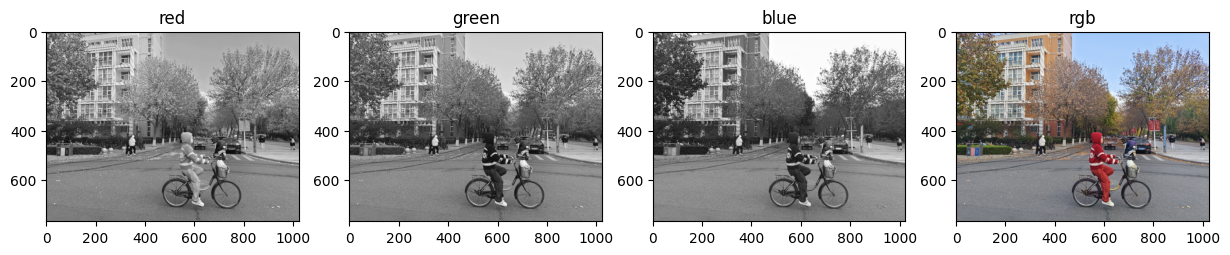

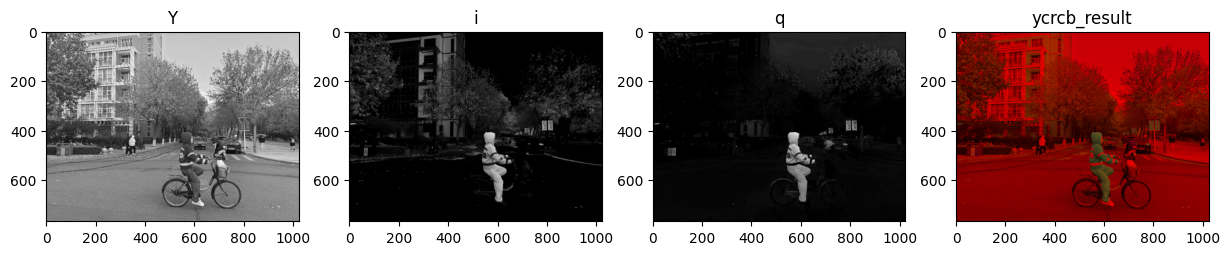

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
def rgb2yiq(rgb):
    rgb=rgb.astype(np.float64)
    yiq = np.array([[0.299,0.587,0.114],[0.596,-0.274,-0.322],[0.211,-0.523,0.312]]).T    
    result_einsum = np.einsum('ijk,ks->ijs',rgb,yiq) 
    result = np.clip(np.around(result_einsum,decimals = 0),0,255).astype(np.uint8)
    return result

bgr = cv2.imread('./leaves/IMG_20241104_074700.jpg')
bgr = cv2.resize(bgr,(1024,768))
b,g,r  = cv2.split(bgr)
rgb = cv2.merge([r,g,b])
yiq_result = rgb2yiq(rgb)

fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(r,cmap = 'gray')
ax[0].set_title('red')
ax[1].imshow(g,cmap ='gray')
ax[1].set_title('green')
ax[2].imshow(b,cmap ='gray')
ax[2].set_title('blue')
ax[3].imshow(rgb)
ax[3].set_title('rgb')

y,i,q = cv2.split(yiq_result)
fig,ax = plt.subplots(1,4,figsize=(15,5),dpi = 100)
ax[0].imshow(y,cmap = 'gray')
ax[0].set_title('Y')
ax[1].imshow(i,cmap ='gray')
ax[1].set_title('i')
ax[2].imshow(q,cmap ='gray')
ax[2].set_title('q')
ax[3].imshow(yiq_result)
ax[3].set_title('ycrcb_result')

